# Étape 1 — Analyse, validation et normalisation de MultiDoc2Dial

Ce notebook constitue le premier livrable du projet GovAssist. Il permet de :

1. télécharger et découvrir le dataset officiel ;
2. analyser documents, domaines, sections, spans et conversations ;
3. contrôler les doublons, offsets et références `doc_id/id_sp` ;
4. produire un rapport de qualité reproductible ;
5. transformer MultiDoc2Dial dans un schéma interne indépendant du format source.

Les cellules sont volontairement non exécutées : lance-les dans l'ordre et inspecte chaque résultat avant de continuer.

## 1. Installation des dépendances d'exploration

Cette étape utilise uniquement `pandas` et `matplotlib` en plus de la bibliothèque standard Python.

In [1]:
%pip install -q pandas matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from __future__ import annotations

import hashlib
import json
import re
import urllib.request
import zipfile
from collections import Counter, defaultdict
from datetime import datetime, timezone
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR
RAW_DIR = PROJECT_ROOT / "data" / "raw" / "multidoc2dial"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / "multidoc2dial_v1"
REPORT_DIR = PROJECT_ROOT / "reports" / "generated" / "multidoc2dial_v1"
DATASET_URL = "https://doc2dial.github.io/multidoc2dial/file/multidoc2dial.zip"
ZIP_PATH = RAW_DIR / "multidoc2dial.zip"

print(f"Project root : {PROJECT_ROOT}")
print(f"Raw data     : {RAW_DIR}")
print(f"Processed    : {PROCESSED_DIR}")

Project root : C:\Users\dhiar\OneDrive\Bureau\Project\RAG Assistant
Raw data     : C:\Users\dhiar\OneDrive\Bureau\Project\RAG Assistant\data\raw\multidoc2dial
Processed    : C:\Users\dhiar\OneDrive\Bureau\Project\RAG Assistant\data\processed\multidoc2dial_v1


## 2. Téléchargement reproductible

Le téléchargement est ignoré si l'archive existe déjà. L'extraction vérifie que l'archive ne peut pas écrire en dehors du dossier cible.

In [3]:
def download_file(url: str, destination: Path) -> None:
    destination.parent.mkdir(parents=True, exist_ok=True)
    if destination.exists():
        print(f"Archive déjà présente : {destination}")
        return

    request = urllib.request.Request(url, headers={"User-Agent": "GovAssist/0.1"})
    temporary = destination.with_suffix(destination.suffix + ".part")
    with urllib.request.urlopen(request) as response, temporary.open("wb") as output:
        while block := response.read(1024 * 1024):
            output.write(block)
    temporary.replace(destination)
    print(f"Archive téléchargée : {destination} ({destination.stat().st_size:,} octets)")


def safe_extract(archive_path: Path, destination: Path) -> None:
    extraction_marker = destination / ".extracted"
    if extraction_marker.exists():
        print(f"Archive déjà extraite : {destination}")
        return

    destination.mkdir(parents=True, exist_ok=True)
    resolved_destination = destination.resolve()
    with zipfile.ZipFile(archive_path) as archive:
        for member in archive.infolist():
            target = (destination / member.filename).resolve()
            if not target.is_relative_to(resolved_destination):
                raise ValueError(f"Chemin dangereux dans l'archive : {member.filename}")
        archive.extractall(destination)
    extraction_marker.touch()
    print(f"Archive extraite : {destination}")


download_file(DATASET_URL, ZIP_PATH)
safe_extract(ZIP_PATH, RAW_DIR / "extracted")

Archive déjà présente : C:\Users\dhiar\OneDrive\Bureau\Project\RAG Assistant\data\raw\multidoc2dial\multidoc2dial.zip
Archive déjà extraite : C:\Users\dhiar\OneDrive\Bureau\Project\RAG Assistant\data\raw\multidoc2dial\extracted


## 3. Découverte et chargement des fichiers

Le code cherche les fichiers récursivement afin de ne pas dépendre du dossier intermédiaire présent dans l'archive.

In [4]:
EXPECTED_FILES = {
    "documents": "multidoc2dial_doc.json",
    "train": "multidoc2dial_dial_train.json",
    "validation": "multidoc2dial_dial_validation.json",
    "test": "multidoc2dial_dial_test.json",
}


def find_unique_file(root: Path, filename: str) -> Path:
    matches = [path for path in root.rglob(filename) if "__MACOSX" not in path.parts]
    if len(matches) != 1:
        raise FileNotFoundError(f"Attendu 1 fichier {filename}, trouvé {len(matches)} : {matches}")
    return matches[0]


def load_json(path: Path) -> dict[str, Any]:
    with path.open("r", encoding="utf-8") as handle:
        value = json.load(handle)
    if not isinstance(value, dict):
        raise TypeError(f"La racine JSON de {path} doit être un objet")
    return value


dataset_files = {
    name: find_unique_file(RAW_DIR / "extracted", filename)
    for name, filename in EXPECTED_FILES.items()
}

documents_source = load_json(dataset_files["documents"])["doc_data"]
dialogues_source = {
    split: load_json(dataset_files[split])["dial_data"]
    for split in ("train", "validation", "test")
}

pd.DataFrame(
    [{"type": name, "file": path.name, "size_mb": path.stat().st_size / 1_000_000}
     for name, path in dataset_files.items()]
).round(2)

,type,file,size_mb
0,documents,multidoc2dial_doc.json,46.22
1,train,multidoc2dial_dial_train.json,36.36
2,validation,multidoc2dial_dial_validation.json,6.94
3,test,multidoc2dial_dial_test.json,6.65


## 4. Analyse des documents, sections et spans

In [5]:
def normalize_text(text: str) -> str:
    return " ".join(text.casefold().split())


def text_hash(text: str) -> str:
    return hashlib.sha256(normalize_text(text).encode("utf-8")).hexdigest()


document_rows: list[dict[str, Any]] = []
document_lookup: dict[str, dict[str, Any]] = {}
span_ids_by_document: dict[str, set[str]] = defaultdict(set)
duplicate_document_ids: list[str] = []
invalid_span_offsets: list[dict[str, Any]] = []
span_text_mismatches: list[dict[str, Any]] = []
section_metadata_conflicts: list[dict[str, Any]] = []
invalid_section_offsets: list[dict[str, Any]] = []
section_offset_mismatches: list[dict[str, Any]] = []
spans_outside_section_range: list[dict[str, Any]] = []

for map_domain, domain_documents in documents_source.items():
    for map_doc_id, document in domain_documents.items():
        doc_id = document.get("doc_id", map_doc_id)
        if doc_id in document_lookup:
            duplicate_document_ids.append(doc_id)
        document_lookup[doc_id] = document
        doc_text = document.get("doc_text", "")
        raw_spans = document.get("spans", {})
        sections: dict[str, list[dict[str, Any]]] = defaultdict(list)

        for map_span_id, span in raw_spans.items():
            span_id = str(span.get("id_sp", map_span_id))
            span_ids_by_document[doc_id].add(span_id)
            section_id = str(span.get("id_sec", f"missing:{span_id}"))
            sections[section_id].append(span)

            start, end = span.get("start_sp"), span.get("end_sp")
            if not isinstance(start, int) or not isinstance(end, int) or not 0 <= start <= end <= len(doc_text):
                invalid_span_offsets.append({"doc_id": doc_id, "span_id": span_id, "start": start, "end": end})
            elif doc_text[start:end] != span.get("text_sp"):
                span_text_mismatches.append({"doc_id": doc_id, "span_id": span_id})

        for section_id, section_spans in sections.items():
            signatures = {
                json.dumps(
                    {
                        "start": span.get("start_sec"),
                        "end": span.get("end_sec"),
                        "text": span.get("text_sec"),
                        "title": span.get("title"),
                        "parents": span.get("parent_titles", []),
                    },
                    ensure_ascii=False,
                    sort_keys=True,
                )
                for span in section_spans
            }
            if len(signatures) > 1:
                section_metadata_conflicts.append({"doc_id": doc_id, "section_id": section_id})

            representative = section_spans[0]
            start, end = representative.get("start_sec"), representative.get("end_sec")
            if not isinstance(start, int) or not isinstance(end, int) or not 0 <= start <= end <= len(doc_text):
                invalid_section_offsets.append(
                    {"doc_id": doc_id, "section_id": section_id, "start": start, "end": end}
                )
            elif doc_text[start:end] != representative.get("text_sec"):
                section_offset_mismatches.append({"doc_id": doc_id, "section_id": section_id})

            if isinstance(start, int) and isinstance(end, int):
                for section_span in section_spans:
                    span_start, span_end = section_span.get("start_sp"), section_span.get("end_sp")
                    if (
                        isinstance(span_start, int)
                        and isinstance(span_end, int)
                        and not start <= span_start <= span_end <= end
                    ):
                        spans_outside_section_range.append(
                            {
                                "doc_id": doc_id,
                                "section_id": section_id,
                                "span_id": str(section_span.get("id_sp", "")),
                            }
                        )

        document_rows.append(
            {
                "doc_id": doc_id,
                "domain": map_domain,
                "title": document.get("title", ""),
                "characters": len(doc_text),
                "words": len(re.findall(r"\w+", doc_text)),
                "sections": len(sections),
                "spans": len(raw_spans),
                "content_hash": text_hash(doc_text),
            }
        )

documents_df = pd.DataFrame(document_rows)
display(documents_df.head())
display(documents_df.groupby("domain").agg(documents=("doc_id", "count"), median_words=("words", "median"), median_sections=("sections", "median"), median_spans=("spans", "median")).round(1))
display(documents_df[["characters", "words", "sections", "spans"]].describe(percentiles=[0.5, 0.95]).round(1))

,doc_id,domain,title,characters,words,sections,spans,content_hash
0,Benefits Planner: Survivors | Planning For Your Survivors | Social Security Administration#1_0,ssa,Benefits Planner: Survivors | Planning For Your Survivors | Social Security Administration#1,6726,1153,39,99,a186d21fe37e80553afbffb80747f020e92d7080d2e646c72118f44c79e80caa
1,Benefits Planner: Survivors | Planning For Your Survivors | Social Security Administration#2_0,ssa,Benefits Planner: Survivors | Planning For Your Survivors | Social Security Administration#2,6665,1146,38,98,88e0a7ff0e0477b9af958e0c262e57614c828e095f5b0c4f774dfd7f061ab0ad
2,Benefits Planner: Disability | How You Apply | Social Security Administration#1_0,ssa,Benefits Planner: Disability | How You Apply | Social Security Administration#1,3291,544,27,65,fe87bbb0ecbd1c47528cf14e1f525dc73f8c84978fcadfd68b896aea076773dc
3,Benefits Planner: Disability | How You Apply | Social Security Administration#2_0,ssa,Benefits Planner: Disability | How You Apply | Social Security Administration#2,3243,538,26,64,95e2df4f73cb67259a8559dd447502b2665d96ebbb6d0c187e01bade9dbbdd20
4,Learn what documents you will need to get a Social Security Card | Social Security Administration#2_0,ssa,Learn what documents you will need to get a Social Security Card | Social Security Administration#2,3247,561,19,63,d4f68a5bd2a8b576ede284ff36ad22c1e1d999efe64c06c4f0509862ebafb2a8


,documents,median_words,median_sections,median_spans
domain,,,,
dmv,149,704.0,25.0,66.0
ssa,109,561.0,19.0,63.0
studentaid,92,604.0,22.0,48.5
va,138,661.5,26.0,64.0


,characters,words,sections,spans
count,488.0,488.0,488.0,488.0
mean,4743.1,807.3,27.5,73.1
std,3631.0,609.1,16.1,48.4
min,866.0,137.0,6.0,12.0
50%,3911.5,660.0,24.0,63.0
95%,10279.6,1742.3,56.0,149.0
max,44837.0,7293.0,165.0,504.0


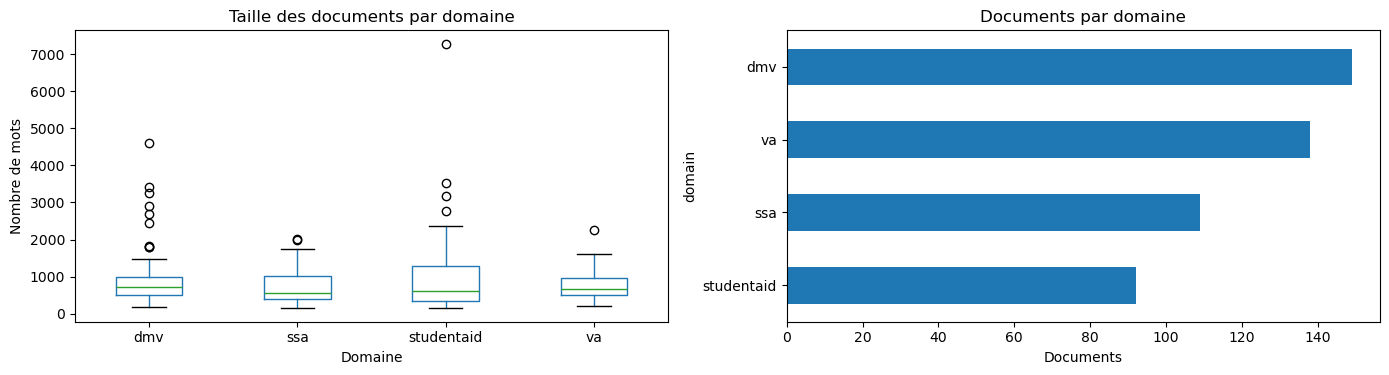

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
documents_df.boxplot(column="words", by="domain", ax=axes[0], grid=False)
axes[0].set_title("Taille des documents par domaine")
axes[0].set_ylabel("Nombre de mots")
axes[0].set_xlabel("Domaine")
documents_df.groupby("domain")["doc_id"].count().sort_values().plot.barh(ax=axes[1])
axes[1].set_title("Documents par domaine")
axes[1].set_xlabel("Documents")
plt.suptitle("")
plt.tight_layout()
plt.show()

### Doublons documentaires

On conserve les doublons à cette étape, mais on leur attribue le même `content_hash`. La décision de déduplication sera prise explicitement lors du chunking/indexing.

In [7]:
duplicate_documents_df = (
    documents_df[documents_df.duplicated("content_hash", keep=False)]
    .sort_values(["content_hash", "doc_id"])
    [["domain", "doc_id", "title", "words", "content_hash"]]
)

print(f"Groupes de contenu dupliqué : {duplicate_documents_df['content_hash'].nunique()}")
print(f"Documents appartenant à ces groupes : {len(duplicate_documents_df)}")
display(duplicate_documents_df)

Groupes de contenu dupliqué : 10
Documents appartenant à ces groupes : 23


,domain,doc_id,title,words,content_hash
6,ssa,Learn what documents you will need to get a Social Security Card | Social Security Administration#4_0,Learn what documents you will need to get a Social Security Card | Social Security Administration#4,542,0540b7bdc48abc90fd9d9521aae0b28b7f61441f91dd18bcbdef317fb900e76c
98,ssa,Learn what documents you will need to get a Social Security Card | Social Security Administration#4_0_1,Learn what documents you will need to get a Social Security Card | Social Security Administration#4,542,0540b7bdc48abc90fd9d9521aae0b28b7f61441f91dd18bcbdef317fb900e76c
99,ssa,Learn what documents you will need to get a Social Security Card | Social Security Administration#4_0_1_2,Learn what documents you will need to get a Social Security Card | Social Security Administration#4,542,0540b7bdc48abc90fd9d9521aae0b28b7f61441f91dd18bcbdef317fb900e76c
94,ssa,Benefits Planner | Social Security Credits and Benefit Eligibility | SSA#1_0,Benefits Planner | Social Security Credits and Benefit Eligibility | SSA#1,688,076a847dd9948323e32d75bd2a471d3940b71d09e319ba1d24374a906eff9899
95,ssa,Benefits Planner | Social Security Credits and Benefit Eligibility | SSA#2_0,Benefits Planner | Social Security Credits and Benefit Eligibility | SSA#2,688,076a847dd9948323e32d75bd2a471d3940b71d09e319ba1d24374a906eff9899
8,ssa,Learn what documents you will need to get a Social Security Card | Social Security Administration#6_0,Learn what documents you will need to get a Social Security Card | Social Security Administration#6,1096,0b91f82fb2480c9457e27bce0adea7b639826f72ac97d6c20345945f4396455c
100,ssa,Learn what documents you will need to get a Social Security Card | Social Security Administration#6_0_1_2,Learn what documents you will need to get a Social Security Card | Social Security Administration#6,1096,0b91f82fb2480c9457e27bce0adea7b639826f72ac97d6c20345945f4396455c
101,ssa,Learn what documents you will need to get a Social Security Card | Social Security Administration#6_0_1_2_3,Learn what documents you will need to get a Social Security Card | Social Security Administration#6,1096,0b91f82fb2480c9457e27bce0adea7b639826f72ac97d6c20345945f4396455c
102,ssa,Learn what documents you will need to get a Social Security Card | Social Security Administration#6_0_1_2_3_4,Learn what documents you will need to get a Social Security Card | Social Security Administration#6,1096,0b91f82fb2480c9457e27bce0adea7b639826f72ac97d6c20345945f4396455c
10,ssa,Learn what documents you will need to get a Social Security Card | Social Security Administration#8_0,Learn what documents you will need to get a Social Security Card | Social Security Administration#8,469,6d91c2159ac0b9d5d2dc3c1228afb1b891f5ecf275797b67d74b1580f110240b


## 5. Analyse des dialogues

In [8]:
conversation_rows: list[dict[str, Any]] = []
turn_rows: list[dict[str, Any]] = []
reference_rows: list[dict[str, Any]] = []
seen_dialogue_ids: set[str] = set()
duplicate_dialogue_ids: list[str] = []
non_monotonic_dialogues: list[str] = []

for split, domains in dialogues_source.items():
    for domain, dialogues in domains.items():
        for dialogue in dialogues:
            dial_id = dialogue.get("dial_id", "")
            if dial_id in seen_dialogue_ids:
                duplicate_dialogue_ids.append(dial_id)
            seen_dialogue_ids.add(dial_id)
            turns = dialogue.get("turns", [])
            turn_ids = [turn.get("turn_id") for turn in turns]
            if any(a >= b for a, b in zip(turn_ids, turn_ids[1:])):
                non_monotonic_dialogues.append(dial_id)

            conversation_signature = text_hash("\n".join(str(turn.get("utterance", "")) for turn in turns))
            conversation_rows.append(
                {
                    "dial_id": dial_id,
                    "split": split,
                    "domain": domain,
                    "turn_count": len(turns),
                    "conversation_hash": conversation_signature,
                }
            )

            for turn in turns:
                references = turn.get("references", [])
                turn_rows.append(
                    {
                        "dial_id": dial_id,
                        "split": split,
                        "domain": domain,
                        "turn_id": turn.get("turn_id"),
                        "role": turn.get("role"),
                        "dialogue_act": turn.get("da"),
                        "utterance": turn.get("utterance", ""),
                        "reference_count": len(references),
                    }
                )
                for reference in references:
                    reference_rows.append(
                        {
                            "dial_id": dial_id,
                            "split": split,
                            "dialogue_domain": domain,
                            "turn_id": turn.get("turn_id"),
                            "doc_id": reference.get("doc_id"),
                            "id_sp": str(reference.get("id_sp", "")),
                            "label": reference.get("label"),
                        }
                    )

conversations_df = pd.DataFrame(conversation_rows)
turns_df = pd.DataFrame(turn_rows)
references_df = pd.DataFrame(reference_rows)

display(conversations_df.groupby("split").agg(dialogues=("dial_id", "count"), turns=("turn_count", "sum"), median_turns=("turn_count", "median"), max_turns=("turn_count", "max")))
display(conversations_df.groupby("domain")["dial_id"].count().to_frame("dialogues"))
display(turns_df["role"].value_counts().to_frame("turns"))
display(turns_df["dialogue_act"].value_counts().to_frame("turns"))

,dialogues,turns,median_turns,max_turns
split,,,,
test,661,8938,13.0,20
train,3474,48002,14.0,24
validation,661,9195,14.0,20


,dialogues
domain,
dmv,1328
ssa,1191
studentaid,940
va,1337


,turns
role,
agent,33869
user,32266


,turns
dialogue_act,
respond_solution,23209
query_condition,22437
query_solution,9808
response_positive,3938
response_negative,3833
respond_no_solution,1822
respond_solution_positive,629
respond_solution_negative,459


## 6. Intégrité des références `doc_id/id_sp`

In [9]:
document_domain_by_id = {row["doc_id"]: row["domain"] for row in document_rows}

references_df["document_exists"] = references_df["doc_id"].isin(document_lookup)
references_df["span_exists"] = references_df.apply(
    lambda row: row["id_sp"] in span_ids_by_document.get(row["doc_id"], set()),
    axis=1,
)
references_df["same_domain"] = references_df.apply(
    lambda row: document_domain_by_id.get(row["doc_id"]) == row["dialogue_domain"],
    axis=1,
)

broken_document_references = references_df[~references_df["document_exists"]]
broken_span_references = references_df[references_df["document_exists"] & ~references_df["span_exists"]]
cross_domain_references = references_df[references_df["document_exists"] & ~references_df["same_domain"]]
duplicate_conversations_df = conversations_df[conversations_df.duplicated("conversation_hash", keep=False)]

integrity_summary = pd.DataFrame(
    [
        {"check": "duplicate_document_ids", "count": len(duplicate_document_ids), "severity": "error"},
        {"check": "invalid_span_offsets", "count": len(invalid_span_offsets), "severity": "error"},
        {"check": "invalid_section_offsets", "count": len(invalid_section_offsets), "severity": "error"},
        {"check": "span_text_mismatches", "count": len(span_text_mismatches), "severity": "error"},
        {"check": "broken_document_references", "count": len(broken_document_references), "severity": "error"},
        {"check": "broken_span_references", "count": len(broken_span_references), "severity": "error"},
        {"check": "duplicate_dialogue_ids", "count": len(duplicate_dialogue_ids), "severity": "error"},
        {"check": "non_monotonic_dialogues", "count": len(non_monotonic_dialogues), "severity": "error"},
        {"check": "cross_domain_references", "count": len(cross_domain_references), "severity": "warning"},
        {"check": "section_metadata_conflicts", "count": len(section_metadata_conflicts), "severity": "warning"},
        {"check": "section_offset_mismatches", "count": len(section_offset_mismatches), "severity": "warning"},
        {"check": "spans_outside_section_range", "count": len(spans_outside_section_range), "severity": "warning"},
        {"check": "duplicate_document_records", "count": len(duplicate_documents_df), "severity": "warning"},
        {"check": "duplicate_conversations", "count": len(duplicate_conversations_df), "severity": "warning"},
    ]
)
display(integrity_summary)

blocking_errors = integrity_summary.query("severity == 'error' and count > 0")
if len(blocking_errors):
    display(blocking_errors)
    raise ValueError("Le dataset contient des erreurs bloquantes. Corrige-les avant la transformation.")

print("✅ Aucun problème d'intégrité bloquant détecté.")

,check,count,severity
0,duplicate_document_ids,0,error
1,invalid_span_offsets,0,error
2,invalid_section_offsets,0,error
3,span_text_mismatches,0,error
4,broken_document_references,0,error
5,broken_span_references,0,error
6,duplicate_dialogue_ids,0,error
7,non_monotonic_dialogues,0,error
8,cross_domain_references,0,warning
9,section_metadata_conflicts,80,warning


✅ Aucun problème d'intégrité bloquant détecté.


## 7. Schéma interne canonique

Le format interne conserve la structure `Document → Section → Span` et `Conversation → Turn → Reference`. Les IDs internes sont déterministes ; les IDs MultiDoc2Dial sont conservés uniquement comme provenance.

```text
Document
├── id, domain, title, text, content_hash
├── provenance.source_document_id
└── sections[]
    ├── id, source_section_id, title, text
    ├── start_char, end_char, offset_semantics
    ├── parent_titles[]
    └── spans[]
        └── id, source_span_id, text, offsets, within_section_range

Conversation
├── id, split, domain, source_dialogue_id
└── turns[]
    ├── role, dialogue_act, utterance
    └── references[] → document_id, section_id, span_id
```

`text` représente le contenu direct de la section. Dans quelques sections parentes, le range source `start_char:end_char` englobe aussi les sous-sections. `offset_semantics` vaut donc `exact_text_range` ou `subtree_range`. Le booléen `within_section_range` signale aussi les rattachements span/section incohérents dans la source. Le futur chunker doit prendre `text` et les offsets exacts des spans comme autorités, sans reconstruire aveuglément une section depuis son range.

In [10]:
SCHEMA_VERSION = "1.0.0"


def canonical_id(entity: str, *parts: str) -> str:
    payload = "\x1f".join((entity, *parts)).encode("utf-8")
    return f"{entity}_{hashlib.sha256(payload).hexdigest()[:24]}"


def choose_section_text(spans: list[dict[str, Any]]) -> str:
    candidates = [str(span.get("text_sec", "")) for span in spans]
    return max(set(candidates), key=lambda value: (candidates.count(value), len(value), value))


def choose_section_title(spans: list[dict[str, Any]], section_text: str) -> str | None:
    normalized_section = normalize_text(section_text)
    titles = [str(span["title"]).strip() for span in spans if str(span.get("title", "")).strip()]
    exact_matches = [title for title in titles if normalize_text(title) == normalized_section]
    if exact_matches:
        return exact_matches[-1]
    if not titles:
        return None
    frequencies = Counter(titles)
    maximum = max(frequencies.values())
    return next(title for title in reversed(titles) if frequencies[title] == maximum)


def choose_parent_titles(spans: list[dict[str, Any]]) -> list[dict[str, str | None]]:
    candidates = [span.get("parent_titles", []) for span in spans if isinstance(span.get("parent_titles", []), list)]
    if not candidates:
        return []
    serialized = [json.dumps(value, ensure_ascii=False, sort_keys=True) for value in candidates]
    selected = json.loads(Counter(serialized).most_common(1)[0][0])
    headings = []
    for item in selected:
        if isinstance(item, dict) and str(item.get("text", "")).strip():
            headings.append(
                {
                    "source_span_id": str(item.get("id_sp")) if item.get("id_sp") is not None else None,
                    "text": str(item["text"]).strip(),
                    "level": str(item.get("level")) if item.get("level") is not None else None,
                }
            )
    return headings


def classify_section_range(doc_text: str, section_text: str, start: Any, end: Any) -> str:
    if not isinstance(start, int) or not isinstance(end, int) or not 0 <= start <= end <= len(doc_text):
        return "invalid_source_range"
    if doc_text[start:end] == section_text:
        return "exact_text_range"
    # Certains ranges de section parent englobent leurs sous-sections, alors que
    # text_sec contient uniquement le texte direct de la section.
    return "subtree_range"


def is_span_within_section_range(span: dict[str, Any], section: dict[str, Any]) -> bool:
    span_start, span_end = span.get("start_sp"), span.get("end_sp")
    section_start, section_end = section.get("start_sec"), section.get("end_sec")
    return (
        isinstance(span_start, int)
        and isinstance(span_end, int)
        and isinstance(section_start, int)
        and isinstance(section_end, int)
        and section_start <= span_start <= span_end <= section_end
    )

## 8. Transformation des documents

In [11]:
canonical_documents: list[dict[str, Any]] = []
canonical_document_lookup: dict[str, str] = {}
canonical_span_lookup: dict[tuple[str, str], tuple[str, str]] = {}

for domain, domain_documents in documents_source.items():
    for map_doc_id, document in domain_documents.items():
        source_doc_id = str(document.get("doc_id", map_doc_id))
        internal_doc_id = canonical_id("doc", domain, source_doc_id)
        doc_text = document.get("doc_text", "")
        canonical_document_lookup[source_doc_id] = internal_doc_id
        grouped_spans: dict[str, list[dict[str, Any]]] = defaultdict(list)

        for map_span_id, span in document.get("spans", {}).items():
            source_span_id = str(span.get("id_sp", map_span_id))
            source_section_id = str(span.get("id_sec", f"missing:{source_span_id}"))
            grouped_spans[source_section_id].append(span)

        canonical_sections: list[dict[str, Any]] = []
        for source_section_id, spans in sorted(
            grouped_spans.items(),
            key=lambda item: (min(span.get("start_sec", 10**18) for span in item[1]), item[0]),
        ):
            spans = sorted(spans, key=lambda span: (span.get("start_sp", 0), str(span.get("id_sp", ""))))
            representative = spans[0]
            internal_section_id = canonical_id("sec", source_doc_id, source_section_id)
            section_text = choose_section_text(spans)
            canonical_spans = []

            for span in spans:
                source_span_id = str(span.get("id_sp", ""))
                internal_span_id = canonical_id("span", source_doc_id, source_span_id)
                canonical_span_lookup[(source_doc_id, source_span_id)] = (internal_span_id, internal_section_id)
                canonical_spans.append(
                    {
                        "id": internal_span_id,
                        "source_span_id": source_span_id,
                        "source_tag": span.get("tag"),
                        "text": span.get("text_sp", ""),
                        "start_char": span.get("start_sp"),
                        "end_char": span.get("end_sp"),
                        "within_section_range": is_span_within_section_range(span, representative),
                    }
                )

            canonical_sections.append(
                {
                    "id": internal_section_id,
                    "source_section_id": source_section_id,
                    "title": choose_section_title(spans, section_text),
                    "parent_titles": choose_parent_titles(spans),
                    "text": section_text,
                    "start_char": representative.get("start_sec"),
                    "end_char": representative.get("end_sec"),
                    # Certains ranges source couvrent aussi les sous-sections. Le champ
                    # explicite évite qu'un consommateur suppose que doc_text[start:end] == text.
                    "offset_semantics": classify_section_range(
                        doc_text, section_text, representative.get("start_sec"), representative.get("end_sec")
                    ),
                    "spans": canonical_spans,
                }
            )

        canonical_documents.append(
            {
                "schema_version": SCHEMA_VERSION,
                "id": internal_doc_id,
                "domain": domain,
                "title": document.get("title", ""),
                "text": doc_text,
                "content_hash": text_hash(doc_text),
                "provenance": {
                    "dataset": "multidoc2dial",
                    "dataset_version": "1.0",
                    "source_document_id": source_doc_id,
                },
                "sections": canonical_sections,
            }
        )

canonical_documents.sort(key=lambda document: (document["domain"], document["id"]))
print(f"Documents canoniques : {len(canonical_documents):,}")
print(f"Sections canoniques  : {sum(len(doc['sections']) for doc in canonical_documents):,}")

Documents canoniques : 488
Sections canoniques  : 13,421


## 9. Transformation des conversations et résolution des références

In [12]:
canonical_conversations: list[dict[str, Any]] = []

for split, domains in dialogues_source.items():
    for domain, dialogues in domains.items():
        for dialogue in dialogues:
            source_dialogue_id = str(dialogue.get("dial_id", ""))
            conversation_id = canonical_id("conv", split, source_dialogue_id)
            canonical_turns = []

            for position, turn in enumerate(dialogue.get("turns", [])):
                turn_index = turn.get("turn_id", position)
                canonical_references = []
                for reference in turn.get("references", []):
                    source_doc_id = str(reference.get("doc_id", ""))
                    source_span_id = str(reference.get("id_sp", ""))
                    resolved_span = canonical_span_lookup.get((source_doc_id, source_span_id))
                    canonical_references.append(
                        {
                            "document_id": canonical_document_lookup.get(source_doc_id),
                            "section_id": resolved_span[1] if resolved_span else None,
                            "span_id": resolved_span[0] if resolved_span else None,
                            "source_document_id": source_doc_id,
                            "source_span_id": source_span_id,
                            "label": reference.get("label"),
                            "is_resolved": source_doc_id in canonical_document_lookup and resolved_span is not None,
                        }
                    )

                canonical_turns.append(
                    {
                        "id": canonical_id("turn", conversation_id, str(turn_index)),
                        "index": turn_index,
                        "role": turn.get("role"),
                        "dialogue_act": turn.get("da"),
                        "utterance": turn.get("utterance", ""),
                        "references": canonical_references,
                    }
                )

            canonical_conversations.append(
                {
                    "schema_version": SCHEMA_VERSION,
                    "id": conversation_id,
                    "source_dialogue_id": source_dialogue_id,
                    "split": split,
                    "domain": domain,
                    "turns": canonical_turns,
                }
            )

canonical_conversations.sort(key=lambda conversation: (conversation["split"], conversation["domain"], conversation["id"]))
unresolved_references = [
    reference
    for conversation in canonical_conversations
    for turn in conversation["turns"]
    for reference in turn["references"]
    if not reference["is_resolved"]
]
print(f"Conversations canoniques : {len(canonical_conversations):,}")
print(f"Références non résolues   : {len(unresolved_references):,}")
assert not unresolved_references, "La transformation contient des références non résolues."

Conversations canoniques : 4,796
Références non résolues   : 0


## 10. Écriture atomique des artefacts

Les fichiers temporaires sont remplacés uniquement après une écriture complète. Le manifeste conserve les hashes des entrées et sorties.

In [13]:
def file_sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        while block := handle.read(1024 * 1024):
            digest.update(block)
    return digest.hexdigest()


def write_jsonl_atomic(path: Path, records: list[dict[str, Any]]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary = path.with_suffix(path.suffix + ".tmp")
    with temporary.open("w", encoding="utf-8", newline="\n") as handle:
        for record in records:
            handle.write(json.dumps(record, ensure_ascii=False, separators=(",", ":")))
            handle.write("\n")
    temporary.replace(path)


def write_json_atomic(path: Path, value: dict[str, Any]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary = path.with_suffix(path.suffix + ".tmp")
    temporary.write_text(json.dumps(value, ensure_ascii=False, indent=2) + "\n", encoding="utf-8")
    temporary.replace(path)


def numeric_profile(series: pd.Series) -> dict[str, int | float]:
    return {
        "count": int(series.count()),
        "min": int(series.min()),
        "mean": round(float(series.mean()), 2),
        "median": float(series.median()),
        "p95": float(series.quantile(0.95)),
        "max": int(series.max()),
    }


documents_output = PROCESSED_DIR / "documents.jsonl"
conversations_output = PROCESSED_DIR / "conversations.jsonl"
write_jsonl_atomic(documents_output, canonical_documents)
write_jsonl_atomic(conversations_output, canonical_conversations)

document_profile_by_domain = {
    str(domain): {
        "documents": int(len(group)),
        "words": numeric_profile(group["words"]),
        "sections": numeric_profile(group["sections"]),
        "spans": numeric_profile(group["spans"]),
    }
    for domain, group in documents_df.groupby("domain", sort=True)
}
conversation_profile_by_split = {
    str(split): {
        "dialogues": int(len(group)),
        "turns_per_dialogue": numeric_profile(group["turn_count"]),
    }
    for split, group in conversations_df.groupby("split", sort=True)
}
section_range_semantics = Counter(
    section["offset_semantics"]
    for document in canonical_documents
    for section in document["sections"]
)
duplicate_groups = [
    {
        "content_hash": content_hash,
        "documents": group[["doc_id", "domain", "title"]].to_dict(orient="records"),
    }
    for content_hash, group in duplicate_documents_df.groupby("content_hash", sort=True)
]
warning_findings = int(integrity_summary.loc[integrity_summary["severity"] == "warning", "count"].sum())

audit_report = {
    "schema_version": SCHEMA_VERSION,
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
    "inventory": {
        "documents": len(documents_df),
        "sections": int(documents_df["sections"].sum()),
        "spans": int(documents_df["spans"].sum()),
        "dialogues": len(conversations_df),
        "turns": len(turns_df),
        "references": len(references_df),
    },
    "documents_by_domain": documents_df["domain"].value_counts().sort_index().to_dict(),
    "dialogues_by_split": conversations_df["split"].value_counts().sort_index().to_dict(),
    "document_profile_by_domain": document_profile_by_domain,
    "conversation_profile_by_split": conversation_profile_by_split,
    "turns_by_role": {str(key): int(value) for key, value in turns_df["role"].value_counts().items()},
    "turns_by_dialogue_act": {
        str(key): int(value) for key, value in turns_df["dialogue_act"].value_counts().items()
    },
    "section_range_semantics": dict(sorted(section_range_semantics.items())),
    "integrity_checks": integrity_summary.to_dict(orient="records"),
    "duplicate_document_groups": int(duplicate_documents_df["content_hash"].nunique()),
    "duplicate_document_records": int(len(duplicate_documents_df)),
    "duplicate_groups": duplicate_groups,
    "quality_notes": {
        "section_offset_mismatches": (
            "Anomalie structurelle non bloquante : certains ranges de sections parentes incluent leurs "
            "sous-sections, tandis que text contient uniquement le contenu direct. offset_semantics le signale."
        ),
        "duplicate_documents": (
            "Les documents de contenu identique restent séparés afin de préserver les références source. "
            "Le content_hash permettra leur déduplication contrôlée pendant l'indexation."
        ),
        "spans_outside_section_range": (
            "Anomalie source non bloquante : les offsets et textes des spans restent exacts, mais certains "
            "rattachements à une section ont un range parent incohérent. within_section_range le signale."
        ),
    },
}
REPORT_DIR.mkdir(parents=True, exist_ok=True)
write_json_atomic(REPORT_DIR / "audit_report.json", audit_report)

manifest = {
    "schema_version": SCHEMA_VERSION,
    "pipeline_stage": "01_data_analysis_validation",
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
    "source_files": {
        name: {"path": str(path.relative_to(PROJECT_ROOT)), "sha256": file_sha256(path), "bytes": path.stat().st_size}
        for name, path in dataset_files.items()
    },
    "outputs": {
        "documents.jsonl": {"records": len(canonical_documents), "sha256": file_sha256(documents_output)},
        "conversations.jsonl": {"records": len(canonical_conversations), "sha256": file_sha256(conversations_output)},
    },
    "quality": {
        "status": "passed" if not len(blocking_errors) and not unresolved_references else "failed",
        "blocking_errors": int(len(blocking_errors)),
        "warning_findings": warning_findings,
        "unresolved_references": len(unresolved_references),
    },
}
write_json_atomic(PROCESSED_DIR / "manifest.json", manifest)
display(pd.DataFrame(manifest["outputs"]).T)

,records,sha256
documents.jsonl,488,21f704ddab631dfc99e59eab88887bb020a670f046f81aba7ac0a167afebad6b
conversations.jsonl,4796,faf10d1b3922b50bcbf768afb0b1e8258e26c20314efcc1177cdcd0f3232e67a


## 11. Validation finale des fichiers produits

In [14]:
canonical_doc_ids: set[str] = set()
canonical_section_ids: set[str] = set()
canonical_span_ids: set[str] = set()
canonical_span_parent: dict[str, tuple[str, str]] = {}
validated_section_semantics: Counter[str] = Counter()
validated_documents = 0
validated_spans_outside_section_range = 0

with documents_output.open(encoding="utf-8") as handle:
    for line_number, line in enumerate(handle, start=1):
        document = json.loads(line)
        required = {"schema_version", "id", "domain", "title", "text", "content_hash", "provenance", "sections"}
        assert required <= document.keys(), f"Document invalide ligne {line_number}"
        assert document["schema_version"] == SCHEMA_VERSION
        assert document["domain"] in {"dmv", "ssa", "studentaid", "va"}
        assert document["content_hash"] == text_hash(document["text"])
        source_doc_id = document["provenance"]["source_document_id"]
        assert document["id"] == canonical_id("doc", document["domain"], source_doc_id)
        assert document["id"] not in canonical_doc_ids
        canonical_doc_ids.add(document["id"])
        validated_documents += 1
        for section in document["sections"]:
            assert {"id", "source_section_id", "title", "text", "offset_semantics", "spans"} <= section.keys()
            assert section["id"] == canonical_id("sec", source_doc_id, section["source_section_id"])
            expected_semantics = classify_section_range(
                document["text"], section["text"], section["start_char"], section["end_char"]
            )
            assert section["offset_semantics"] == expected_semantics
            assert expected_semantics != "invalid_source_range"
            validated_section_semantics[expected_semantics] += 1
            assert section["id"] not in canonical_section_ids
            canonical_section_ids.add(section["id"])
            for span in section["spans"]:
                assert span["id"] == canonical_id("span", source_doc_id, span["source_span_id"])
                assert span["id"] not in canonical_span_ids
                canonical_span_ids.add(span["id"])
                canonical_span_parent[span["id"]] = (document["id"], section["id"])
                start, end = span["start_char"], span["end_char"]
                assert 0 <= start <= end <= len(document["text"])
                assert document["text"][start:end] == span["text"]
                expected_containment = section["start_char"] <= start <= end <= section["end_char"]
                assert span["within_section_range"] is expected_containment
                validated_spans_outside_section_range += int(not expected_containment)

canonical_conversation_ids: set[str] = set()
canonical_turn_ids: set[str] = set()
validated_conversations = validated_turns = validated_references = 0
with conversations_output.open(encoding="utf-8") as handle:
    for line_number, line in enumerate(handle, start=1):
        conversation = json.loads(line)
        assert {"schema_version", "id", "source_dialogue_id", "split", "domain", "turns"} <= conversation.keys()
        assert conversation["schema_version"] == SCHEMA_VERSION
        assert conversation["split"] in {"train", "validation", "test"}
        assert conversation["domain"] in {"dmv", "ssa", "studentaid", "va"}
        assert conversation["id"] == canonical_id("conv", conversation["split"], conversation["source_dialogue_id"])
        assert conversation["id"] not in canonical_conversation_ids
        canonical_conversation_ids.add(conversation["id"])
        validated_conversations += 1
        previous_turn_index = None
        for turn in conversation["turns"]:
            assert turn["id"] == canonical_id("turn", conversation["id"], str(turn["index"]))
            assert turn["id"] not in canonical_turn_ids
            canonical_turn_ids.add(turn["id"])
            assert previous_turn_index is None or previous_turn_index < turn["index"]
            previous_turn_index = turn["index"]
            validated_turns += 1
            for reference in turn["references"]:
                assert reference["is_resolved"]
                assert reference["span_id"] in canonical_span_parent
                assert canonical_span_parent[reference["span_id"]] == (
                    reference["document_id"], reference["section_id"]
                )
                validated_references += 1

persisted_manifest = load_json(PROCESSED_DIR / "manifest.json")
persisted_audit = load_json(REPORT_DIR / "audit_report.json")
for source in persisted_manifest["source_files"].values():
    source_path = PROJECT_ROOT / source["path"]
    assert source_path.stat().st_size == source["bytes"]
    assert file_sha256(source_path) == source["sha256"]
for filename, output in persisted_manifest["outputs"].items():
    assert file_sha256(PROCESSED_DIR / filename) == output["sha256"]
assert persisted_manifest["quality"]["status"] == "passed"
assert persisted_manifest["quality"]["blocking_errors"] == 0
assert persisted_manifest["quality"]["unresolved_references"] == 0
assert persisted_manifest["outputs"]["documents.jsonl"]["records"] == validated_documents
assert persisted_manifest["outputs"]["conversations.jsonl"]["records"] == validated_conversations
assert persisted_audit["section_range_semantics"] == dict(sorted(validated_section_semantics.items()))
persisted_checks = {item["check"]: item["count"] for item in persisted_audit["integrity_checks"]}
assert persisted_checks["spans_outside_section_range"] == validated_spans_outside_section_range
assert persisted_audit["inventory"] == {
    "documents": validated_documents,
    "sections": len(canonical_section_ids),
    "spans": len(canonical_span_ids),
    "dialogues": validated_conversations,
    "turns": validated_turns,
    "references": validated_references,
}

validation_result = {
    "documents": validated_documents,
    "sections": len(canonical_section_ids),
    "spans": len(canonical_span_ids),
    "conversations": validated_conversations,
    "turns": validated_turns,
    "references": validated_references,
    "exact_section_ranges": validated_section_semantics["exact_text_range"],
    "subtree_section_ranges": validated_section_semantics["subtree_range"],
    "spans_outside_section_range": validated_spans_outside_section_range,
}
display(pd.Series(validation_result, name="validated_records").to_frame())
print("✅ Les artefacts canoniques sont valides et prêts pour l'étape de chunking.")

,validated_records
documents,488
sections,13421
spans,35659
conversations,4796
turns,66135
references,95964
exact_section_ranges,13369
subtree_section_ranges,52
spans_outside_section_range,71


✅ Les artefacts canoniques sont valides et prêts pour l'étape de chunking.


## 12. Points à vérifier manuellement

Avant de valider cette étape, vérifie :

- la répartition des quatre domaines ;
- les documents les plus courts et les plus longs ;
- les groupes de documents dupliqués ;
- quelques sections marquées `subtree_range` (structure parent/enfants, pas corruption) ;
- plusieurs conversations et leurs références résolues ;
- la structure d'une ligne de `documents.jsonl` et `conversations.jsonl` ;
- que le manifeste indique `quality.status = passed` ;
- que la cellule de validation finale passe sans erreur.

À titre indicatif, l'archive officielle actuelle devrait produire environ 488 documents, 4 796 conversations et aucune référence cassée. Les nombres réellement obtenus dans ton exécution restent la référence.